In [ ]:
import pandas as pd
dta = pd.read_csv('../data/complaints.csv')
dta.shape


In [ ]:
#lowercase column names and replace spaces with underscores
dta.columns = dta.columns.str.lower().str.replace(' ', '_')
dta.head(2)

In [ ]:
dta.head(2)
#convert date received to datetime
dta['date_received'] = pd.to_datetime(dta['date_received'])
#convert date_recieved to date only
dta['date_received'] = dta['date_received'].dt.date
dta['date_received'].head(2)


In [ ]:
#keep only the lat 3 years of data
dta = dta[dta['date_received'] >= pd.to_datetime('2024-11-01').date()]
print(dta.shape)
dta.head(2)


In [ ]:
dta = dta.loc[dta.company.isin(['CAPITAL ONE FINANCIAL CORPORATION',
                          'JPMORGAN CHASE & CO.',
                          "Block, Inc.",
                          "WELLS FARGO & COMPANY",
                          "BANK OF AMERICA, NATIONAL ASSOCIATION",
                          "CITIBANK, N.A.",
                          "Early Warning Services, LLC",
                          "NAVY FEDERAL CREDIT UNION",
                          "SYNCHRONY FINANCIAL",
                          "AMERICAN EXPRESS COMPANY",
                          "DISCOVER BANK",
                          "Paypal Holdings, Inc",
                          "U.S. BANCORP",
                          "Chime Financial Inc",
                          "ALLY FINANCIAL INC."]), :]

In [ ]:
dta.company.value_counts()

In [ ]:
#count null values in each column
print(dta.shape)
dta.isnull().sum()

In [ ]:
dta.head(2)
w_narr = dta.loc[dta.consumer_complaint_narrative.notnull(), :]
print(w_narr.shape)

In [ ]:
w_narr['narr_length'] = w_narr.consumer_complaint_narrative.str.len()
w_narr.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
#drop narrative gt 4930 characters
w_narr = w_narr.loc[w_narr.narr_length <= 4930, :]
print(w_narr.shape)

In [ ]:
#Product/subproduct value counts
w_narr[['product', 'sub-product']].value_counts()
#products / subproducts with less than 1%  complaints
product_counts = w_narr[['product', 'sub-product']].value_counts()
#filter out products with less than 2% complaints
product_counts = product_counts[product_counts <= product_counts.sum() * 0.02]
rare_products = product_counts.index.tolist()
rare_products


In [ ]:
#remove rare products from w_narr
for product, subproduct in rare_products:
    w_narr = w_narr.loc[~((w_narr.product == product) & (w_narr['sub-product'] == subproduct)), :]
print(w_narr.shape)


In [ ]:
#check if gpu is available
import torch
print(torch.cuda.is_available())
# !pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu129 --user

# import torch
# print(torch.cuda.is_available())
#install transformers that is gpu compatible
!pip install transformers 


In [ ]:
#get embedding model from huggingface
from transformers import AutoTokenizer, AutoModel
#load models on gpu if available
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-miniLM-L6-v2")
model = AutoModel.from_pretrained("sentence-transformers/all-miniLM-L6-v2").to(device)
model = model.to(device)

#check model device
next(model.parameters()).device

In [ ]:


def embed_text(text):
    #tokenize text
    inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True).to(device)
    #get model output
    with torch.no_grad():
        outputs = model(**inputs)
    #mean pooling
    embeddings = outputs.last_hidden_state.mean(dim=1)
    return embeddings.cpu().numpy()
#embed all narratives
import numpy as np
embeddings = []
batch_size = 32
for i in range(0, len(w_narr), batch_size):
    print(f"Processing batch {i//batch_size + 1}")
    batch_texts = w_narr['consumer_complaint_narrative'].iloc[i:i+batch_size].tolist()
    batch_embeddings = embed_text(batch_texts)
    embeddings.append(batch_embeddings)
embeddings = np.vstack(embeddings)
print(embeddings.shape)
#save embeddings to pickle file with complaint ids, product, subproduct, company
embeddings_dict = {
    'complaint_id': w_narr['complaint_id'].tolist(),
    'product': w_narr['product'].tolist(),
    'sub-product': w_narr['sub-product'].tolist(),
    'company': w_narr['company'].tolist(),
    'narrative': w_narr['consumer_complaint_narrative'].tolist(),
    'embeddings': embeddings
}
#write to pickle file
import pickle
with open('../data/complaint_embeddings.pkl', 'wb') as f:
    pickle.dump(embeddings_dict, f)
    












In [ ]:
#add complaint_id, date_received, company, and product, subproduct, narrative to embeddings dataframe
embeddings_df = pd.DataFrame(embeddings)
embeddings_df['complaint_id'] = w_narr['complaint_id'].values
embeddings_df['date_received'] = w_narr['date_received'].values
embeddings_df['company'] = w_narr['company'].values
embeddings_df['product'] = w_narr['product'].values
#embeddings_df['sub_product'] = w_narr['sub_product'].values
embeddings_df['consumer_complaint_narrative'] = w_narr['consumer_complaint_narrative'].values
embeddings_df.head(2)
#save embedding to pickle file
embeddings_df.to_pickle('../data/complaint_embeddings.pkl')


In [ ]:
#company value counts
w_narr.company.value_counts()

In [ ]:
#run cluster analysis using dbscan
from sklearn.cluster import HDBSCAN
#run with multiple eps values

eps_values = [1.0, 1.5, 2.0]
summary = pd.DataFrame()
for eps in eps_values:
    clusterer = HDBSCAN(min_cluster_size=50, metric='cosine')
    cluster_labels = clusterer.fit_predict(embeddings)
    silhouette = silhouette_score(embeddings, cluster_labels)
    n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    n_noise = list(cluster_labels).count(-1)
    temp_summary = pd.DataFrame({'eps': [eps],
                                 'n_clusters': [n_clusters],
                                 'n_noise': [n_noise],
                                 'silhouette_score': [silhouette]})
    summary = pd.concat([summary, temp_summary], ignore_index=True)

print(summary)

#write to csv
summary.to_csv('../data/cluster_summary.csv', index=False)  


In [ ]:
from sklearn.utils import resample


N_SAMPLES = 25000 

if len(embeddings) > N_SAMPLES:
    embeddings_subset = resample(embeddings, n_samples=N_SAMPLES, random_state=442)
else:
    embeddings_subset = embeddings

In [ ]:
#cluster embeddings using agglomerative clustering
from sklearn.cluster import AgglomerativeClustering
#try different thresholds for clustering and see how many clusters are formed, get silhouette score
from sklearn.metrics import silhouette_score    
thresholds = [.75, 1, 2.0, 3.0,  4.0, 4.5, 5.0, 5.5, 6.0, 10, 15, 20, 25,28,30, 35,40,45,50]
silhouette_scores = pd.DataFrame()
for thresh in thresholds:
    clustering = AgglomerativeClustering(n_clusters=None, distance_threshold=thresh)
    cluster_labels = clustering.fit_predict(embeddings_subset)
    n_clusters = len(set(cluster_labels))
    if n_clusters > 1 and n_clusters < len(embeddings_subset):
        sil_score = silhouette_score(embeddings_subset, cluster_labels)
        sil_score_dict = {'threshold': thresh, 'n_clusters': n_clusters, 'silhouette_score': sil_score}
        sil_score_df = pd.DataFrame([sil_score_dict])
        silhouette_scores = pd.concat([silhouette_scores, sil_score_df], ignore_index=True)

    else:
        sil_score = None
    print(f"Threshold: {thresh}, Number of clusters: {n_clusters}, Silhouette Score: {sil_score}")
#plot silhouette scores
import matplotlib.pyplot as plt
plt.plot(silhouette_scores['threshold'], silhouette_scores['silhouette_score'], marker='o')
plt.xlabel('Distance Threshold')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Distance Threshold')
plt.show()
# write to csv
silhouette_scores.to_csv('../data/silhouette_scores.csv', index=False)
#get the best threshold based on silhouette score
best_thresh = silhouette_scores.loc[silhouette_scores['silhouette_score'].idxmax(), 'threshold']
print(f"Best Threshold: {best_thresh}")



Cluster subset based on best threshold and then assign all other points to a cluster        

In [ ]:
clustering = AgglomerativeClustering(n_clusters=None, distance_threshold=25)
cluster_labels = clustering.fit_predict(embeddings_subset)


In [ ]:
#for all embeedings not in subset assign cluster labels based on nearest neighbor in subset
from sklearn.neighbors import NearestNeighbors
nn = NearestNeighbors(n_neighbors=1)
nn.fit(embeddings_subset)
distances, indices = nn.kneighbors(embeddings)
#assign cluster labels from subset to all embeddings
embeddings_df['agglomerative_cluster'] = cluster_labels[indices.flatten()]



In [ ]:
#save embeddings with cluster labels to pickle file
embeddings_df.to_pickle('../data/complaint_embeddings_with_clusters.pkl')

In [ ]:
import pandas as pd
import os
embeddings_df = pd.read_pickle('../data/complaint_embeddings_with_clusters.pkl')
print(os.getcwd())
embeddings_df.head(2)

In [2]:
#import embeddings with cluster labels from pickle file
import pandas as pd
embeddings_df = pd.read_pickle('../data/complaint_embeddings_with_clusters.pkl')
embeddings_df.head(2)
#add cluster name column
cluster_names =pd.read_csv('output/cluster_names.csv')
cluster_names.head(2)
#merge on product and cluster label
embeddings_df = embeddings_df.merge(cluster_names, left_on=['product', 'agglomerative_cluster'], right_on=['product', 'cluster_label'], how='left')
embeddings_df.head(2)

,0,1,2,3,4,5,6,7,8,9,...,383,complaint_id,date_received,company,product,consumer_complaint_narrative,agglomerative_cluster,cluster_column,cluster_label,cluster_name
0,-0.370672,-0.297977,0.118031,0.151081,0.284094,-0.118132,0.145074,-0.163338,-0.204628,-0.348756,...,-0.120117,16179108,2025-09-25,WELLS FARGO & COMPANY,Credit reporting or other personal consumer re...,THESE 3 COMPANIES ARE ON MY CREDIT REPORT AND ...,24,cluster_label_20,24.0,Unauthorized/Inaccurate Credit Report Entries
1,-0.111187,-0.089718,0.415655,0.017798,0.136114,-0.181542,0.113605,-0.134354,-0.011274,-0.133676,...,-0.046670,15305109,2025-08-15,CAPITAL ONE FINANCIAL CORPORATION,Credit reporting or other personal consumer re...,"On XX/XX/scrub>, 2025 I received a text saying...",6,cluster_label_20,6.0,**Credit Reporting Errors & Fraudulent Account...


In [ ]:
embeddings_df.columns[-9:]

C:\Users\whdgu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


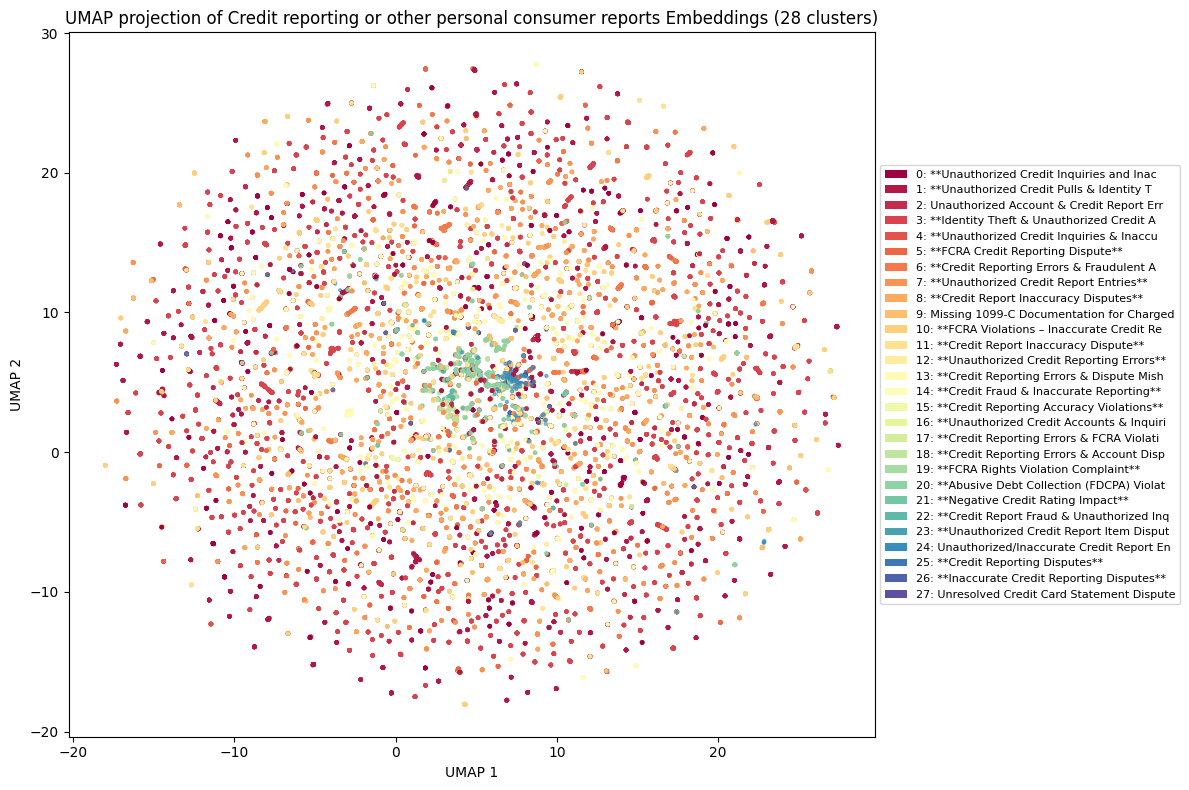

C:\Users\whdgu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


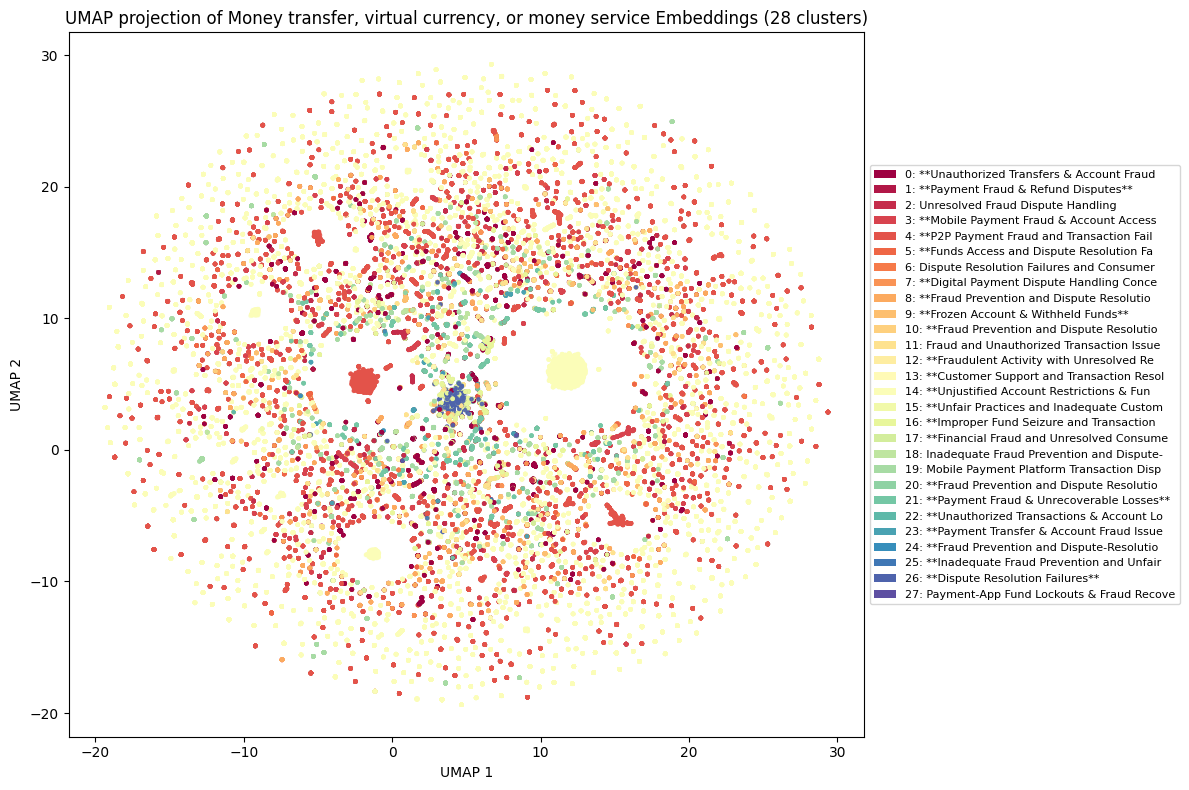

C:\Users\whdgu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


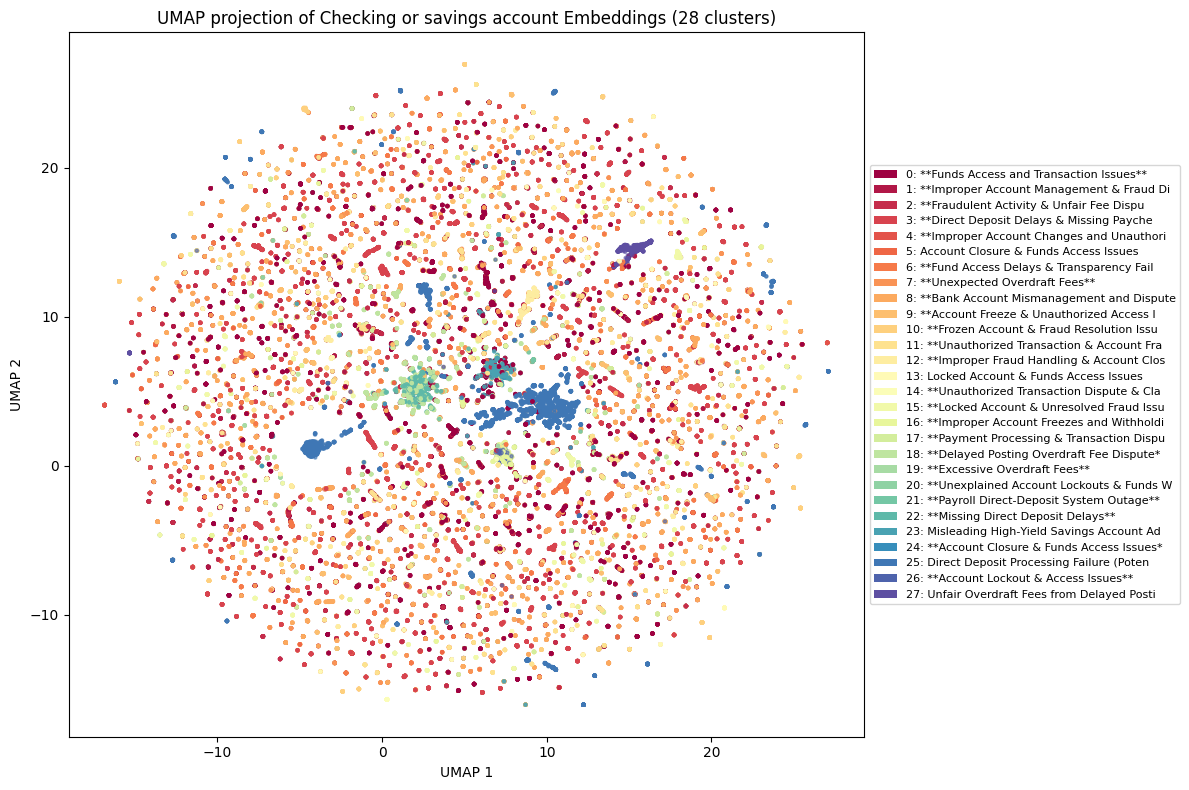

C:\Users\whdgu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


TypeError: 'float' object is not subscriptable

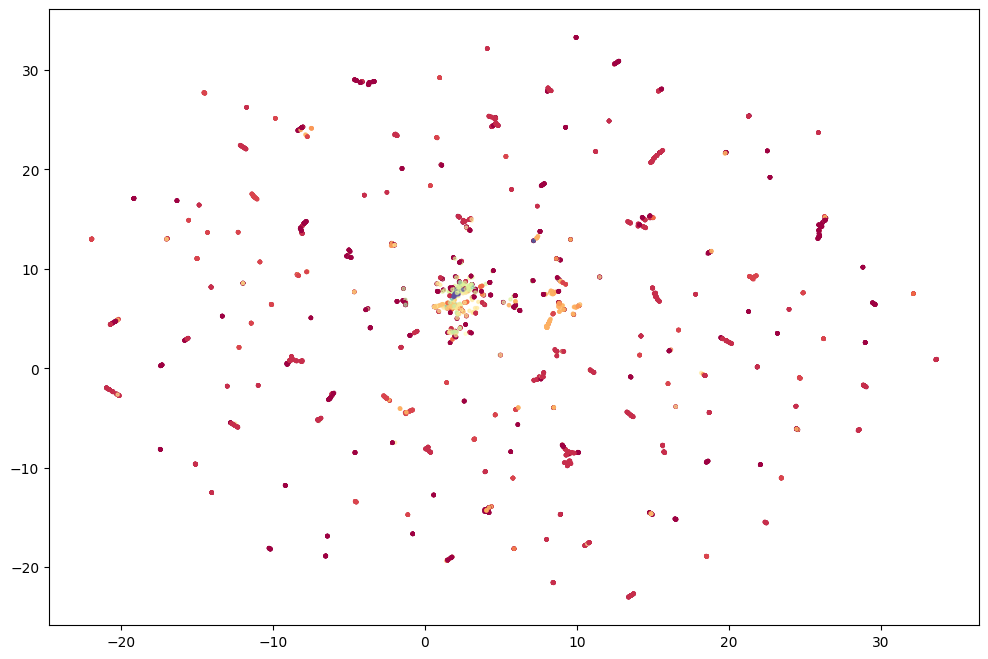

In [6]:
# run umap on embeddings and plot clusters
import umap
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

#convert embeddings to numpy array
#embeddinngs are col 0 to 383
for product in embeddings_df['product'].unique():
    product_mask = embeddings_df['product'] == product
    product_embeddings = embeddings_df.loc[product_mask, embeddings_df.columns[:-9]].values
    cluster_labels = embeddings_df.loc[product_mask, 'agglomerative_cluster'].values
    cluster_names = embeddings_df.loc[product_mask, 'cluster_name'].values
    
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42, init='random')
    embedding_2d = reducer.fit_transform(product_embeddings)
    
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], c=cluster_labels, cmap='Spectral', s=5, alpha=0.6)
    
    # Create legend with cluster names (limit to first 10)
    unique_clusters = np.unique(cluster_labels)
    cluster_to_name = {}
    for cluster in unique_clusters:
        idx = np.where(cluster_labels == cluster)[0][0]
        cluster_to_name[cluster] = cluster_names[idx]
    
    # Show only first 10 clusters in legend
    legend_elements = []
    for i, cluster in enumerate(sorted(unique_clusters)[:35]):
        color = plt.cm.Spectral(i / max(len(unique_clusters) - 1, 1))
        legend_elements.append(Patch(facecolor=color, label=f"{cluster}: {cluster_to_name[cluster][:40]}"))
    
    if len(unique_clusters) > 35:
        legend_elements.append(Patch(facecolor='white', label=f"... and {len(unique_clusters) - 35} more clusters"))
    
    plt.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
    plt.title(f'UMAP projection of {product} Embeddings ({len(unique_clusters)} clusters)')
    plt.xlabel('UMAP 1')
    plt.ylabel('UMAP 2')
    plt.tight_layout()
    plt.savefig(f'plots/umap_{product.replace("/", "_").replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()


In [ ]:
!pip install umap-learn